In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle


path = Path(
    "../data/processed/bars_15s/BTCUSDT/"
    "bars_15s_BTCUSDT_2026_06_11.parquet"
)

df = pd.read_parquet(path)

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True,
)

df = (
    df
    .set_index("timestamp")
    .sort_index()
)

df.head()

,symbol,open,high,low,close,vwap,volume,buy_volume,sell_volume,trade_count
timestamp,,,,,,,,,,
2026-06-11 00:00:00+00:00,BTCUSDT,61511.00,61535.01,61511.00,61529.84,61530.929761,14.08508,1.20852,12.87656,1268
2026-06-11 00:00:15+00:00,BTCUSDT,61530.73,61534.74,61530.72,61534.74,61530.961492,0.35925,0.35560,0.00365,170
2026-06-11 00:00:30+00:00,BTCUSDT,61534.74,61558.00,61534.74,61558.00,61545.700874,1.34527,1.18347,0.16180,890
2026-06-11 00:00:45+00:00,BTCUSDT,61558.00,61574.53,61558.00,61574.52,61566.878010,1.86274,1.82826,0.03448,598
2026-06-11 00:01:00+00:00,BTCUSDT,61574.53,61599.08,61574.52,61592.91,61595.051158,2.36192,1.35038,1.01154,966


In [2]:
day = pd.Timestamp("2026-06-11", tz="UTC")

df_day = df.loc[
    (df.index >= day)
    & (df.index < day + pd.Timedelta(days=1))
].copy()

df_day.head()

,symbol,open,high,low,close,vwap,volume,buy_volume,sell_volume,trade_count
timestamp,,,,,,,,,,
2026-06-11 00:00:00+00:00,BTCUSDT,61511.00,61535.01,61511.00,61529.84,61530.929761,14.08508,1.20852,12.87656,1268
2026-06-11 00:00:15+00:00,BTCUSDT,61530.73,61534.74,61530.72,61534.74,61530.961492,0.35925,0.35560,0.00365,170
2026-06-11 00:00:30+00:00,BTCUSDT,61534.74,61558.00,61534.74,61558.00,61545.700874,1.34527,1.18347,0.16180,890
2026-06-11 00:00:45+00:00,BTCUSDT,61558.00,61574.53,61558.00,61574.52,61566.878010,1.86274,1.82826,0.03448,598
2026-06-11 00:01:00+00:00,BTCUSDT,61574.53,61599.08,61574.52,61592.91,61595.051158,2.36192,1.35038,1.01154,966


In [3]:
print(f"Rows: {len(df_day):,}")
print(f"Start: {df_day.index.min()}")
print(f"End: {df_day.index.max()}")

print()
print(df_day.dtypes)

Rows: 5,760
Start: 2026-06-11 00:00:00+00:00
End: 2026-06-11 23:59:45+00:00

symbol             str
open           float64
high           float64
low            float64
close          float64
vwap           float64
volume         float64
buy_volume     float64
sell_volume    float64
trade_count      int64
dtype: object


In [4]:
invalid_ohlc = df_day.loc[
    (df_day["low"] > df_day["high"])
    | (df_day["open"] < df_day["low"])
    | (df_day["open"] > df_day["high"])
    | (df_day["close"] < df_day["low"])
    | (df_day["close"] > df_day["high"])
]

print(f"Invalid OHLC rows: {len(invalid_ohlc)}")

Invalid OHLC rows: 0


In [5]:
volume_error = (
    df_day["volume"]
    - df_day["buy_volume"]
    - df_day["sell_volume"]
).abs()

print("Maximum volume difference:", volume_error.max())

Maximum volume difference: 1.4210854715202004e-14


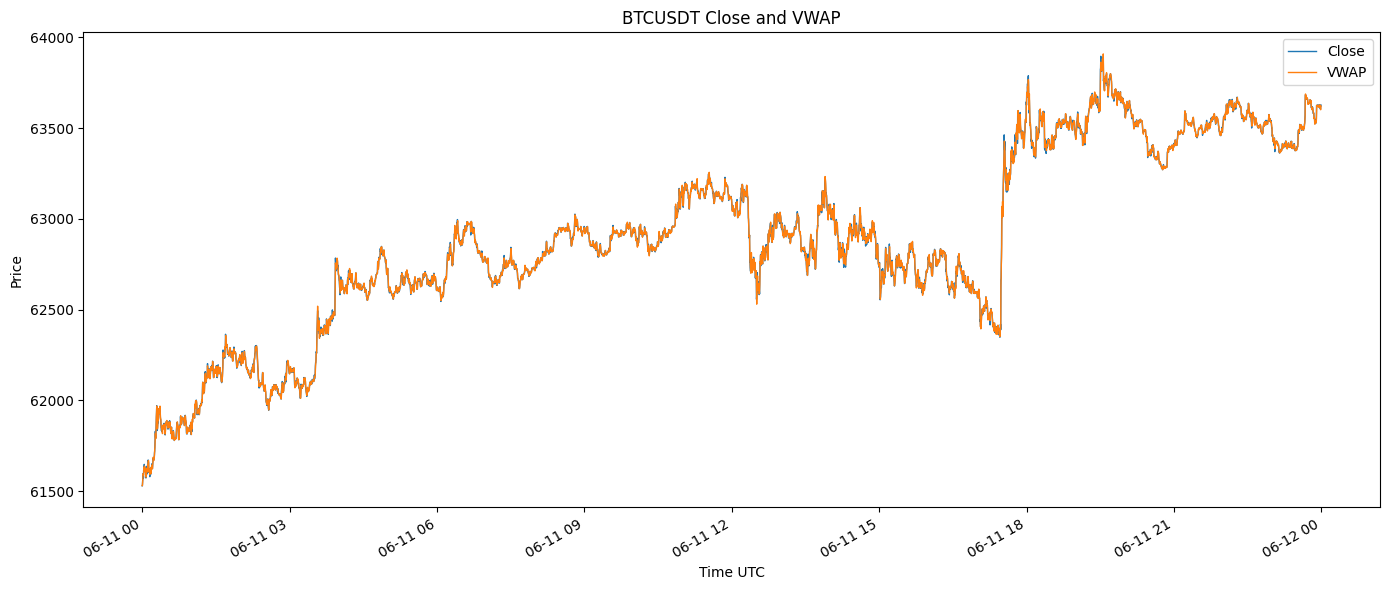

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df_day.index,
    df_day["close"],
    linewidth=1,
    label="Close",
)

ax.plot(
    df_day.index,
    df_day["vwap"],
    linewidth=1,
    label="VWAP",
)

ax.set_title("BTCUSDT Close and VWAP")
ax.set_xlabel("Time UTC")
ax.set_ylabel("Price")
ax.legend()

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


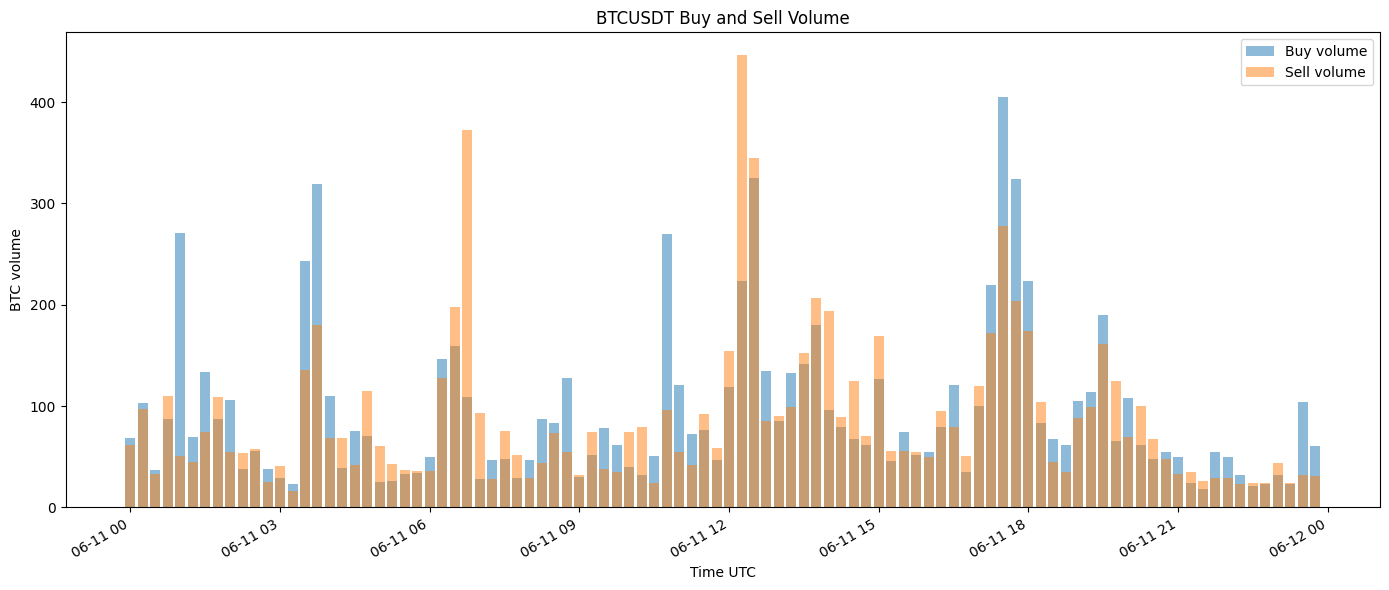

In [7]:
df_5min = (
    df_day[["buy_volume", "sell_volume"]]
    .resample("15min")
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 6))

bar_width = pd.Timedelta(minutes=12)

ax.bar(
    df_5min.index,
    df_5min["buy_volume"],
    width=bar_width,
    alpha=0.50,
    label="Buy volume",
)

ax.bar(
    df_5min.index,
    df_5min["sell_volume"],
    width=bar_width,
    alpha=0.50,
    label="Sell volume",
)

ax.set_title("BTCUSDT Buy and Sell Volume")
ax.set_xlabel("Time UTC")
ax.set_ylabel("BTC volume")
ax.legend()

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


In [8]:
total_volume = (
    df_5min["buy_volume"]
    + df_5min["sell_volume"]
)

df_5min["volume_imbalance"] = np.divide(
    df_5min["buy_volume"] - df_5min["sell_volume"],
    total_volume,
    out=np.zeros(len(df_5min), dtype=float),
    where=total_volume.to_numpy() > 0,
)

df_5min[["buy_volume", "sell_volume", "volume_imbalance"]].head()

,buy_volume,sell_volume,volume_imbalance
timestamp,,,
2026-06-11 00:00:00+00:00,68.98604,61.12412,0.060425
2026-06-11 00:15:00+00:00,102.91942,97.38549,0.027628
2026-06-11 00:30:00+00:00,36.83102,33.02545,0.054477
2026-06-11 00:45:00+00:00,87.10078,110.07056,-0.116497
2026-06-11 01:00:00+00:00,270.40177,50.29399,0.686345


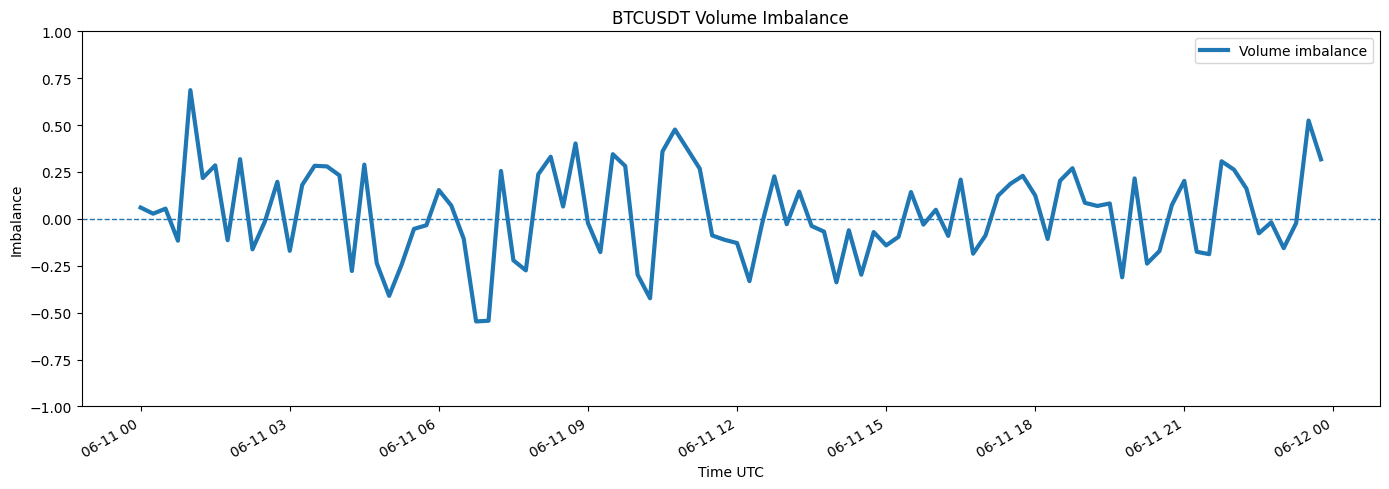

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_5min.index,
    df_5min["volume_imbalance"],
    linewidth=3,
    label="Volume imbalance",
)

ax.axhline(
    y=0,
    linewidth=1,
    linestyle="--",
)

ax.set_title("BTCUSDT Volume Imbalance")
ax.set_xlabel("Time UTC")
ax.set_ylabel("Imbalance")
ax.set_ylim(-1, 1)
ax.legend()

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


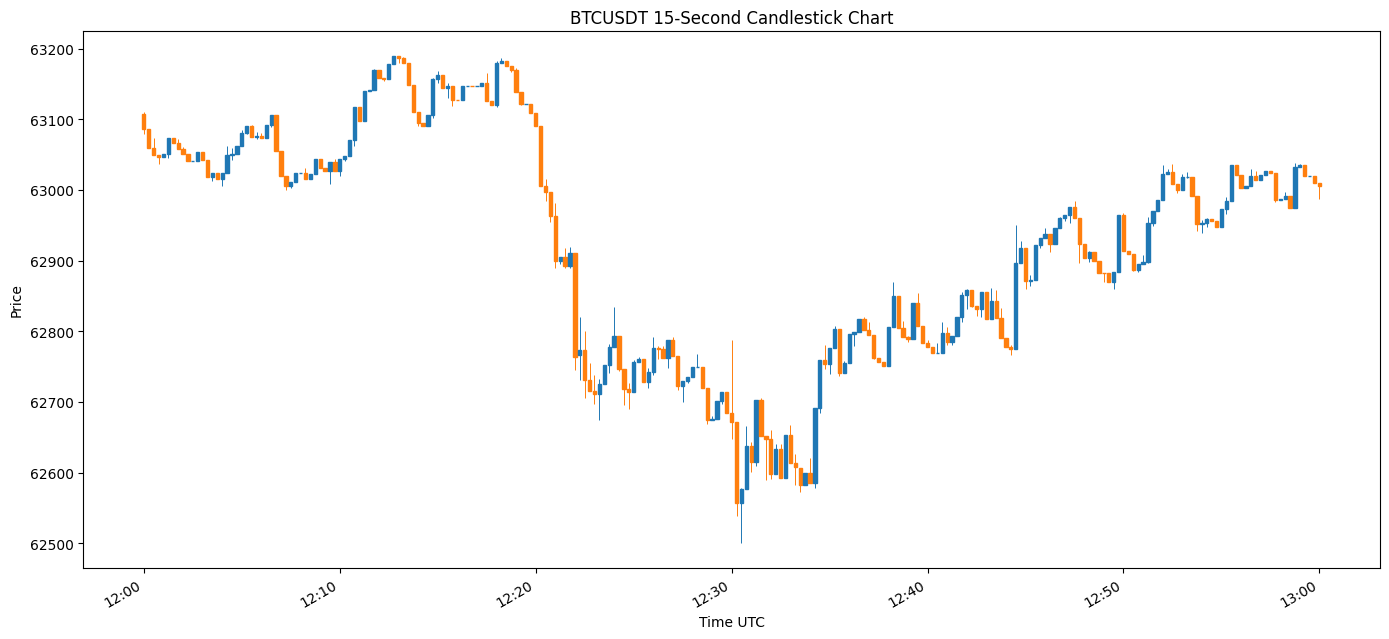

In [10]:
sample = df_day.loc[
    "2026-06-11 12:00:00":
    "2026-06-11 13:00:00"
].copy()

x = mdates.date2num(sample.index.to_pydatetime())
candle_width = 10 / (24 * 60 * 60)

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
up_color = default_colors[0]
down_color = default_colors[1]

fig, ax = plt.subplots(figsize=(14, 6.5))

for x_value, open_price, high_price, low_price, close_price in zip(
    x,
    sample["open"],
    sample["high"],
    sample["low"],
    sample["close"],
):
    candle_color = up_color if close_price >= open_price else down_color

    ax.vlines(
        x_value,
        low_price,
        high_price,
        linewidth=0.7,
        color=candle_color,
    )

    body_bottom = min(open_price, close_price)
    body_height = abs(close_price - open_price)

    if body_height == 0:
        ax.hlines(
            open_price,
            x_value - candle_width / 2,
            x_value + candle_width / 2,
            linewidth=1,
            color=candle_color,
        )
    else:
        ax.add_patch(
            Rectangle(
                (x_value - candle_width / 2, body_bottom),
                candle_width,
                body_height,
                facecolor=candle_color,
                edgecolor=candle_color,
            )
        )

ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.set_title("BTCUSDT 15-Second Candlestick Chart")
ax.set_xlabel("Time UTC")
ax.set_ylabel("Price")

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


/tmp/ipykernel_19592/3700480063.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


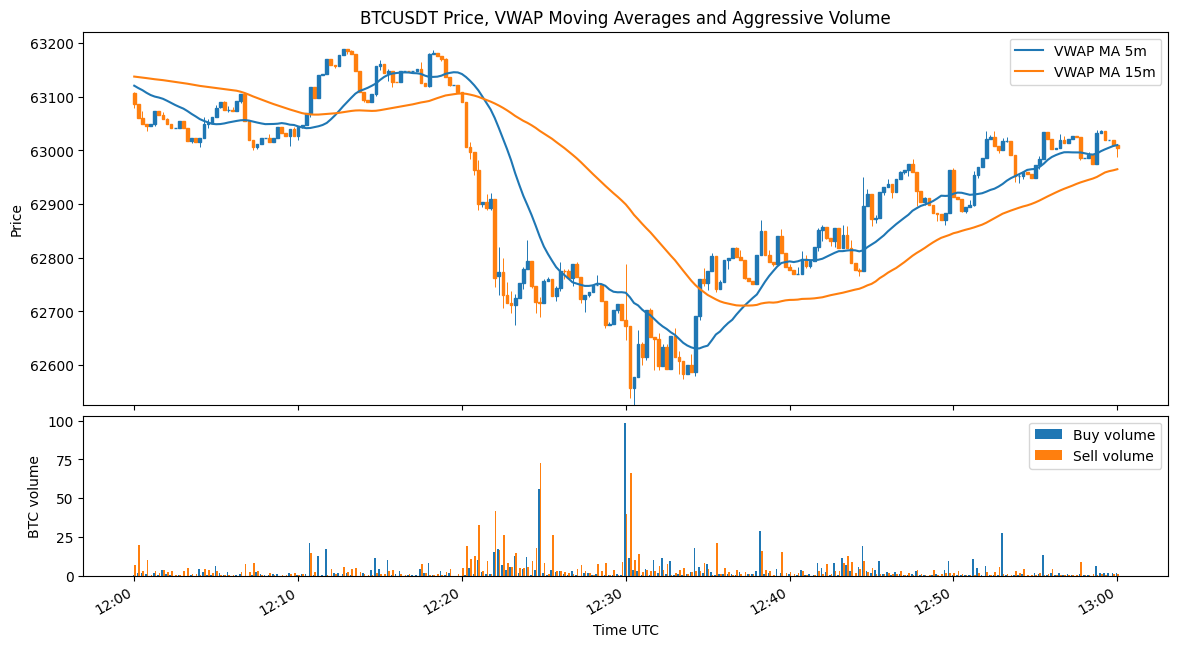

In [11]:
# Moving averages over the 15-second VWAP series
df_day["vwap_ma_5m"] = (
    df_day["vwap"]
    .rolling("5min", min_periods=1)
    .mean()
)

df_day["vwap_ma_15m"] = (
    df_day["vwap"]
    .rolling("15min", min_periods=1)
    .mean()
)


sample = df_day.loc[
    "2026-06-11 12:00:00":
    "2026-06-11 13:00:00"
].copy()

x = mdates.date2num(sample.index.to_pydatetime())
candle_width = 10 / (24 * 60 * 60)
volume_bar_width = 6 / (24 * 60 * 60)

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
up_color = default_colors[0]
down_color = default_colors[1]

fig, (ax_price, ax_volume) = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={
        "height_ratios": [0.7, 0.3],
        "hspace": 0.04,
    },
)

for x_value, open_price, high_price, low_price, close_price in zip(
    x,
    sample["open"],
    sample["high"],
    sample["low"],
    sample["close"],
):
    candle_color = up_color if close_price >= open_price else down_color

    ax_price.vlines(
        x_value,
        low_price,
        high_price,
        linewidth=0.7,
        color=candle_color,
    )

    body_bottom = min(open_price, close_price)
    body_height = abs(close_price - open_price)

    if body_height == 0:
        ax_price.hlines(
            open_price,
            x_value - candle_width / 2,
            x_value + candle_width / 2,
            linewidth=1,
            color=candle_color,
        )
    else:
        ax_price.add_patch(
            Rectangle(
                (x_value - candle_width / 2, body_bottom),
                candle_width,
                body_height,
                facecolor=candle_color,
                edgecolor=candle_color,
            )
        )

ax_price.plot(
    sample.index,
    sample["vwap_ma_5m"],
    linewidth=1.5,
    label="VWAP MA 5m",
)

ax_price.plot(
    sample.index,
    sample["vwap_ma_15m"],
    linewidth=1.5,
    label="VWAP MA 15m",
)

ax_volume.bar(
    x - volume_bar_width / 2,
    sample["buy_volume"],
    width=volume_bar_width,
    label="Buy volume",
)

ax_volume.bar(
    x + volume_bar_width / 2,
    sample["sell_volume"],
    width=volume_bar_width,
    label="Sell volume",
)

ax_price.set_title(
    "BTCUSDT Price, VWAP Moving Averages and Aggressive Volume"
)
ax_price.set_ylabel("Price")
ax_price.legend()

ax_volume.set_xlabel("Time UTC")
ax_volume.set_ylabel("BTC volume")
ax_volume.legend()

ax_volume.xaxis_date()
ax_volume.xaxis.set_major_locator(mdates.AutoDateLocator())
ax_volume.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()
